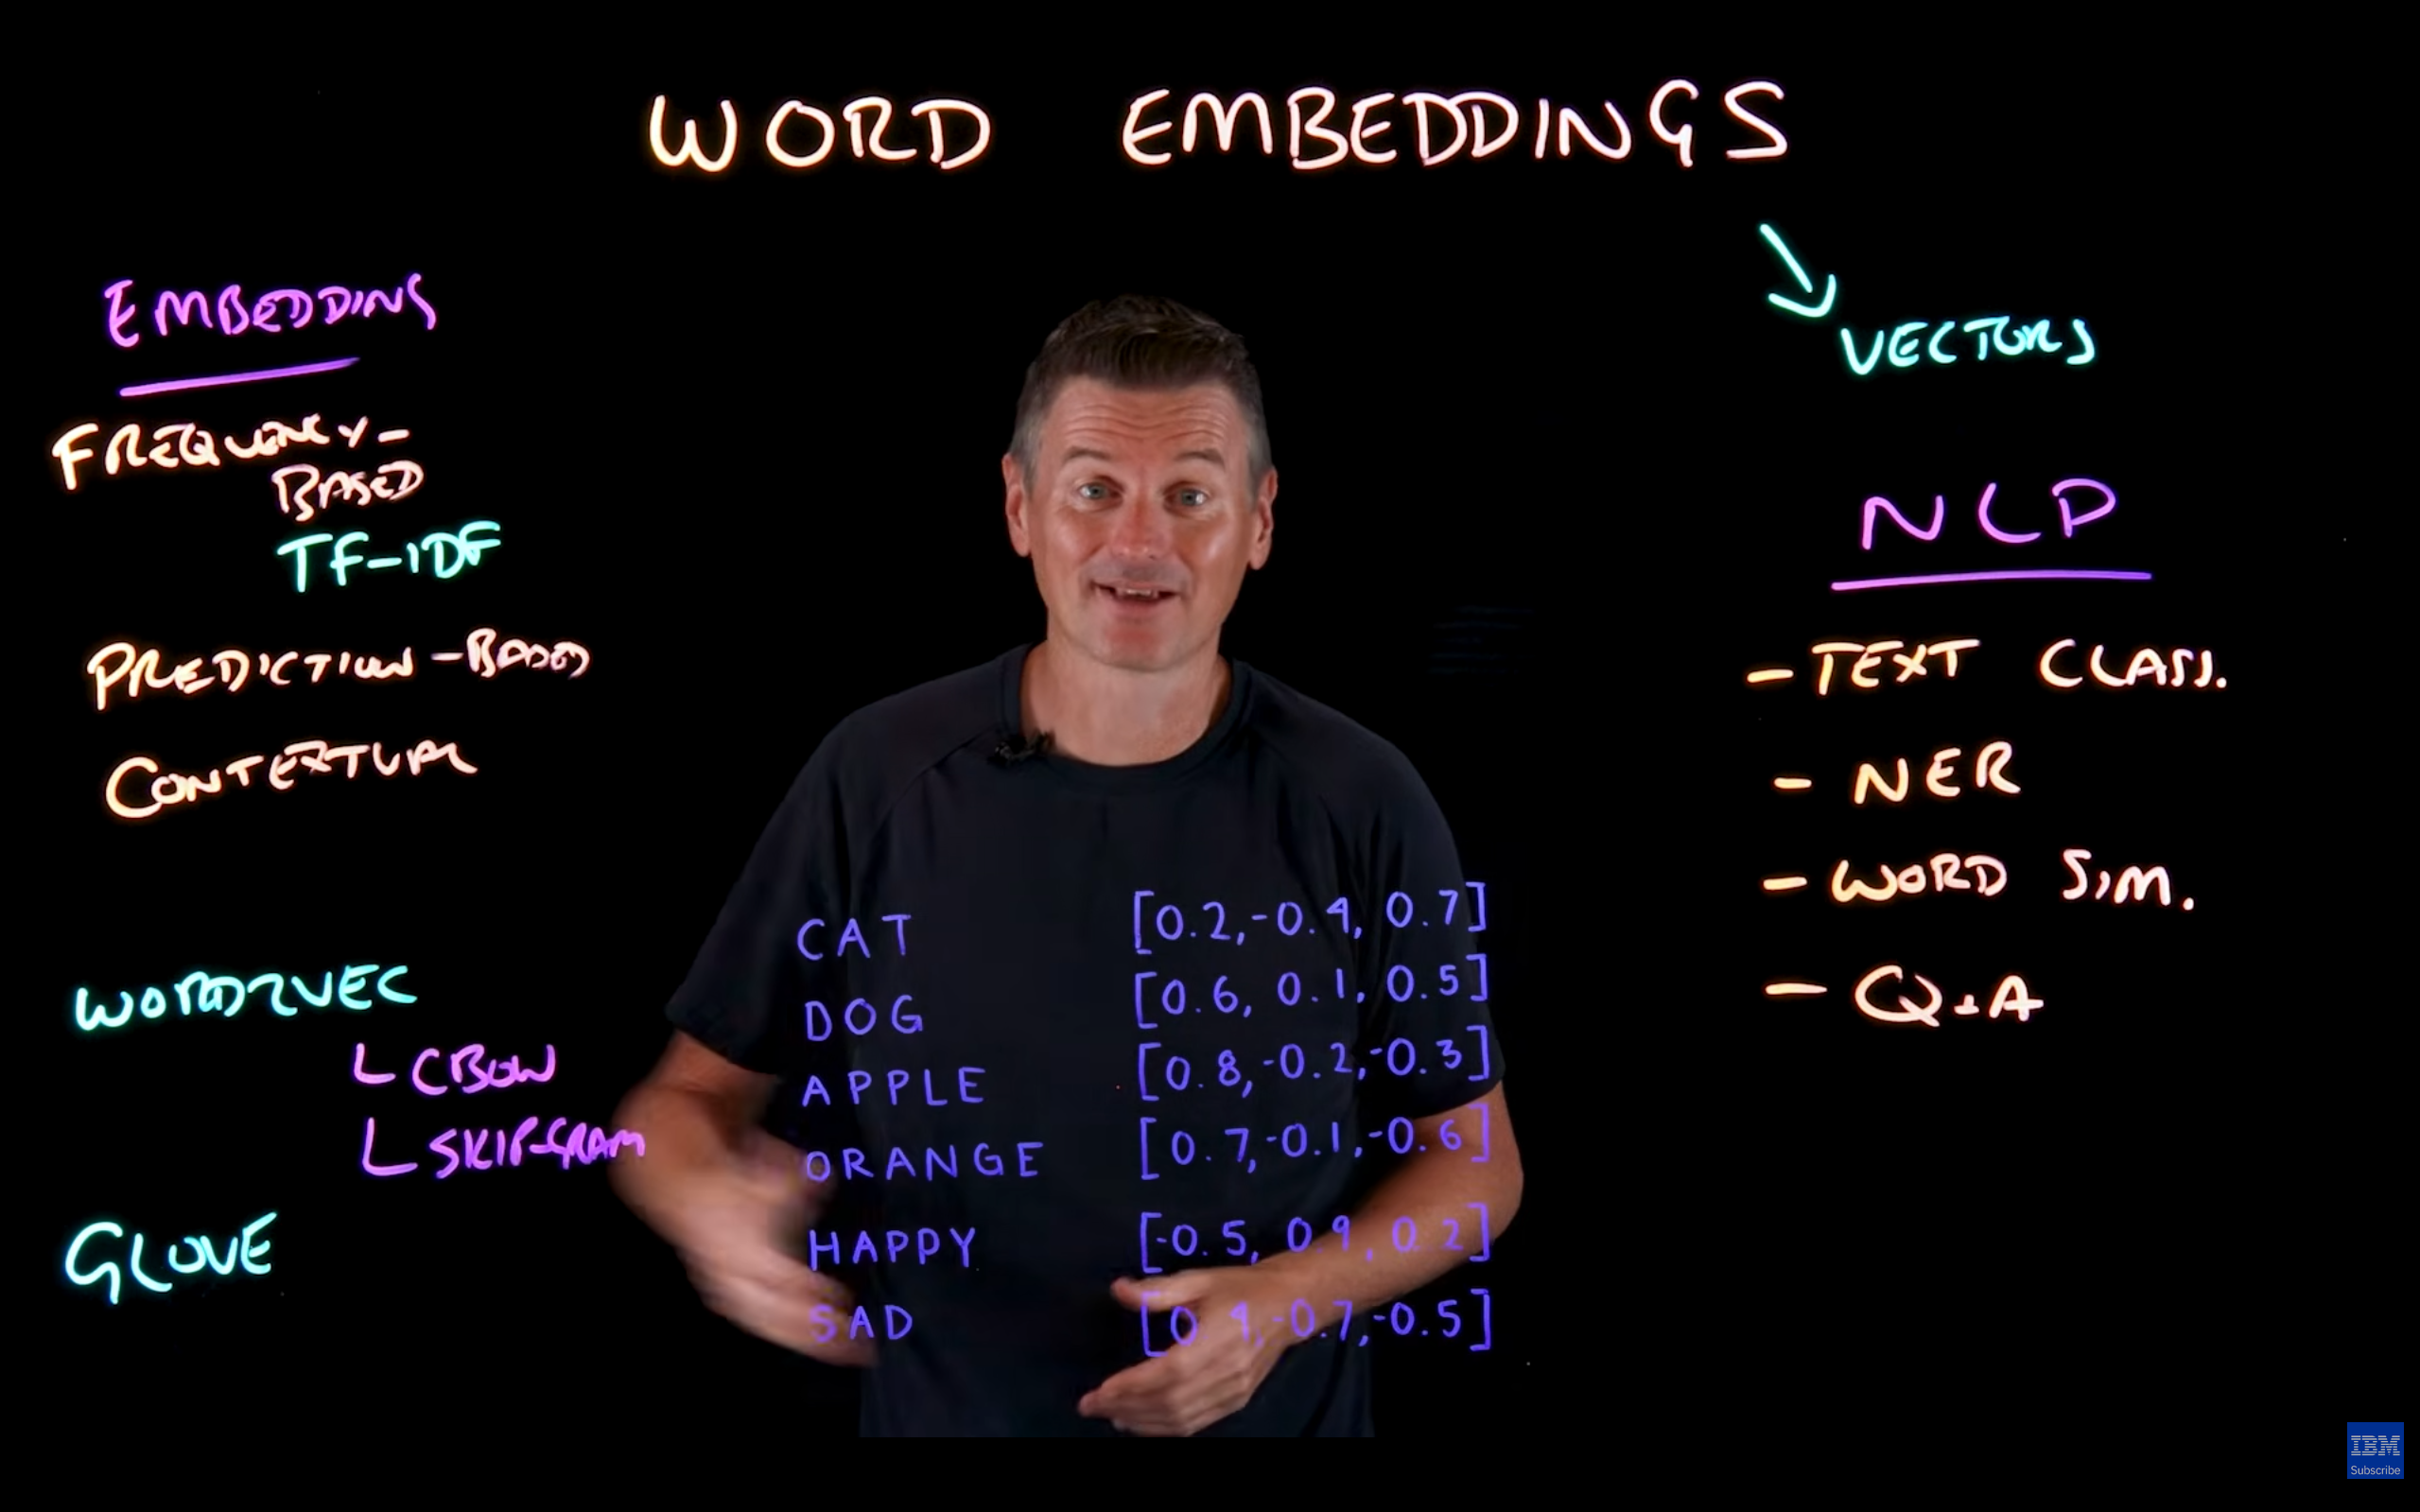

### Embedding

An **embedding** is a way of representing something (like a word, sentence, image, or document) as a **vector of numbers** so that a computer can work with its meaning and relationships mathematically.

For example:

```text
"dog" → [0.21, -0.73, 0.44, 0.91, ...]
"puppy" → [0.19, -0.70, 0.46, 0.89, ...]
"car" → [-0.62, 0.15, 0.83, -0.31, ...]
```

The important part isn't the individual numbers. It's the **position of the vectors relative to each other**.

Because `"dog"` and `"puppy"` have similar meanings, their vectors should be **close together**. `"car"` would be farther away.

> **An embedding converts something meaningful into a numerical vector where similar things tend to have similar vector representations.**

In [9]:
from sentence_transformers import SentenceTransformer

# An embedding model maps text into a fixed-dimensional vector space.
# Each sentence becomes a point in that space, where the relative
# positions of vectors encode semantic relationships learned during training.
model = SentenceTransformer("all-MiniLM-L6-v2")


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

In [10]:
text = "A dog is a loyal domestic animal."

# The model converts the sentence into a 384-dimensional embedding.
# 384 is fixed by this model's architecture; every input produces a vector of the same dimensionality.
embedding = model.encode(text)

print(len(embedding))
# Important: the individual dimensions do not have predefined meanings.
# The semantic information is distributed across the entire vector.

384


In [11]:
text_2 = "Dogs make great pets."

embedding_2 = model.encode(text_2)

print(len(embedding_2))

384


In [12]:
from sklearn.metrics.pairwise import cosine_similarity

similarity = cosine_similarity(
    [embedding],
    [embedding_2]
)

print(similarity)

[[0.5721033]]


### Cosine Similarity

**Cosine similarity** measures how similar two vectors are by calculating the **cosine of the angle between them**.

For embeddings, it tells us how **similar the meanings of two pieces of text are**.

```text
    -1 ─────────── 0 ─────────── +1
    opposite     unrelated       same direction
```

* **+1** → vectors point in the same direction → highly similar
* **0** → vectors are unrelated
* **-1** → vectors point in opposite directions → dissimilar

For example, if the cosine similarity between two sentence embeddings is:

```text
0.5721033
```

The positive value means the sentences have **some degree of semantic similarity**.

### Cosine Similarity in RAG

In **RAG (Retrieval-Augmented Generation)**, documents are first converted into embeddings and stored in a vector database:

```text
Document 1 → vector
Document 2 → vector
Document 3 → vector
Document 4 → vector
```

Suppose the user asks:

```text
"What animals make good pets?"
```

The query is also converted into an embedding. We then compare the **query vector** with the document vectors using cosine similarity:

```text
query
  │
  ├── doc 1 → 0.72
  ├── doc 2 → 0.13
  ├── doc 3 → 0.81
  └── doc 4 → 0.31
```

We then **rank the documents by similarity**:

```text
0.81  ← most similar
0.72
0.31
0.13  ← least similar
```

The highest-scoring documents are considered the **most relevant to the query** and are retrieved for the LLM to use when generating its answer.

In short:

> **Cosine similarity helps RAG find which stored documents are semantically closest to the user's query.**


### Next Step Retrieval

In [17]:
documents = [
    "Dogs are loyal domestic animals.",
    "Cats are independent domestic animals.",
    "A CPU executes instructions in a computer.",
    "Python is a programming language.",
    "The Eiffel Tower is located in Paris.",
    "Elephant are good pets if you have a zoo"
]
# Document is our exmaple Database in which we'll search the user's query

query = "What animals make good pets?"

document_embeddings = model.encode(documents)
query_embedding = model.encode(query)

In [18]:
# Next up we find the cosine similarity of user query vector against every document vector
from sklearn.metrics.pairwise import cosine_similarity

# Compare the query vector against every document vector.
scores = cosine_similarity(
    [query_embedding],
    document_embeddings
)[0]

print(scores)

[0.55516326 0.37829232 0.03521518 0.08897069 0.05643228 0.62986344]


In [19]:
# Now we turn the scores into retrieval
results = list(zip(documents, scores))

# Highest similarity = most relevant to the query.
results.sort(key=lambda x: x[1], reverse=True)

for document, score in results:
    print(f"{score:.3f}  {document}")

0.630  Elephant are good pets if you have a zoo
0.555  Dogs are loyal domestic animals.
0.378  Cats are independent domestic animals.
0.089  Python is a programming language.
0.056  The Eiffel Tower is located in Paris.
0.035  A CPU executes instructions in a computer.


### 1. Why do we need tokens?

A neural network doesn't understand this:

```text
"A dog is loyal."
```

as a string of characters with meaning.

It operates on **numbers**.

So we need:

```text
text
 ↓
tokens
 ↓
token IDs
 ↓
numbers the model can process
```

For example, conceptually:

```text
"A dog is loyal."
       ↓
["A", "dog", "is", "loyal", "."]
       ↓
[42, 3812, 2003, 9342, 13]
```

Those IDs are just integers pointing into the model's **vocabulary**.

The model can then turn those IDs into numerical representations and process them with the Transformer.

---

## 2. Why not just make every word a token?

You might think:

```text
"dog" → token
"cat" → token
"computer" → token
```

Easy.

But language has a ridiculous number of possible words.

Consider:

```text
run
running
runner
runners
rerunning
rerunners
```

If every variation became its own token, the vocabulary would get huge.

And then you encounter:

```text
W41k3R
```

or:

```text
electroencephalographically
```

or a completely new word.

What does the model do then?

---

# 3. Subword tokenization solves this

Modern tokenizers commonly use **subword units**.

So instead of requiring every possible word to exist in the vocabulary:

```text
"unhappiness"
```

might conceptually become:

```text
["un", "happiness"]
```

or perhaps:

```text
["un", "happi", "ness"]
```

depending on the tokenizer.

The model doesn't necessarily care about traditional linguistic words.

It's learning a vocabulary of **frequently useful chunks**.

---

# 4. Who decides how big a token is?

This is the important part.

**The tokenizer's vocabulary and tokenization algorithm determine it.**

The tokenizer is trained beforehand on a large corpus of text.

It learns which pieces occur frequently enough to deserve their own tokens.

For example, suppose the training text frequently contains:

```text
computer
computing
computerized
```

The tokenizer might learn useful pieces such as:

```text
computer
comput
ing
ized
```

Rather than storing every possible word as a separate token.

So token size isn't something the Transformer dynamically decides while reading your sentence.

The **tokenizer has already been trained**, and it applies its learned vocabulary/rules to your text.

---

## 5. Think of the vocabulary as a dictionary of pieces

Imagine a toy vocabulary:

```text
["the", "cat", "dog", "ing", "un", "happy", "ness", "."]
```

Now:

```text
"the dog"
```

might become:

```text
["the", "dog"]
```

while:

```text
"unhappiness"
```

could become:

```text
["un", "happy", "ness"]
```

And each token has an ID:

```text
"un"    → 17
"happy" → 42
"ness"  → 91
```

So ultimately:

```text
"unhappiness"
      ↓
["un", "happy", "ness"]
      ↓
[17, 42, 91]
```

**Those IDs are what enter the model.**

---

## 6. And tokens aren't necessarily words

This is important.

A token can be:

```text
whole word
subword
punctuation
number
whitespace-related piece
sometimes even individual characters/bytes
```

For example, a tokenizer might turn:

```text
"Hello, world!"
```

into something conceptually like:

```text
["Hello", ",", " world", "!"]
```

Notice that **token ≠ word**.

---

# 7. Why does this matter for our embeddings?

Because your pipeline is actually:

```text
"A dog is a loyal domestic animal."
                ↓
            tokenizer
                ↓
          token IDs
                ↓
           Transformer
                ↓
      contextual representations
                ↓
             pooling
                ↓
          384D vector
```

So when we wrote:

```python
embedding = model.encode(text)
```

we were hiding all of that.

**`encode()` isn't directly converting the characters in your string into 384 numbers.**

There's a whole tokenization + Transformer process in between.

And that's why I wanted to introduce tokens now.

---

### One last thing: token count matters

Models don't process unlimited text.

They have a maximum **context length measured in tokens**, not characters or words.

So:

```text
1000 words
```

doesn't necessarily mean:

```text
1000 tokens
```

It could be more or less depending on the text and tokenizer.